In [ ]:
import uproot, pandas as pd, numpy as np
from pathlib import Path

# ---- Configuration --------------------------------------------------------
BASE_DIR  = Path("PPSSP_2026/1l2tau/run2")   # 1 lepton + 2 taus, Run 2
TREE_NAME = "AnalysisMiniTree"
RUN       = 2

# Preselection cuts for the 1L2Tau channel (see README)
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# --- Feature selection policy ---------------------------------------------
# Load generously and let XGBoost prune via importance, BUT never let these
# branches enter as features (they poison the training / leak the label):
#   - weights & scale/fake factors  -> differ systematically signal vs bkg
#   - dsid / eventNumber            -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*    -> generator info, absent in real data
#   - anti-tau bookkeeping          -> fake-region definition, process-dependent
#   - preselection constants        -> n_b_jet==0 always; pass1l2tau==1 always
BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti", "dsid", "eventnumber"]
BLOCK_EXACT  = {"n_b_jet", "pass1l2tau", "hhml_subchannelflavor"}

def is_feature(branch: str) -> bool:
    lb = branch.lower()
    return lb not in BLOCK_EXACT and not any(s in lb for s in BLOCK_SUBSTR)

WEIGHT_PARTS = ["weight", "weight_final"]   # raw branches; w_phys = their product

files = {
    # process    : (filename, label)   1 = signal, 0 = background
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",         0),
}

# Build the feature list from branches COMMON to all files (robust against
# per-sample branch differences; a single-file probe could silently misalign)

common = None

for proc, (fname, _) in files.items():
    keys = set(uproot.open({str(BASE_DIR / fname): TREE_NAME}).keys())
    common = keys if common is None else common & keys
features = sorted(b for b in common if is_feature(b))

print(f"{len(features)} candidate features (common to all {len(files)} files, leakage-free)\n")

# ---- Extraction loop ------------------------------------------------------
dfs = []
for proc, (fname, label) in files.items():
    tree = uproot.open({str(BASE_DIR / fname): TREE_NAME})
    df = tree.arrays(features + WEIGHT_PARTS, cut=PRESELECTION, library="pd")

    """
    'weight'       = sigma*L/sum_w_gen, per DSID+campaign (raw branch, untouched)
    'weight_final' = generator event weight, Sherpa NLO -> negatives (raw branch, untouched)
    'w_phys'       = physical event weight -> use for training & yields
    """

    df["w_phys"]  = df["weight"] * df["weight_final"]
    df["label"]   = label   # 1 = signal, 0 = background
    df["process"] = proc    # keep track of the originating process
    df["run"]     = RUN
    dfs.append(df)
    print(f"{proc:12s}: {len(df):>8d} events after preselection")

data = pd.concat(dfs, ignore_index=True)

# ---- Post-concat cleaning --------------------------------------------------
# 1) Constant / empty features (zero variance, all-NaN or all-sentinel) -> drop

nun = data[features].nunique()
const = nun[nun <= 1].index.tolist()
features = [f for f in features if f not in const]
data = data.drop(columns=const)
print(f"\nDropped {len(const)} constant/empty features:\n  {sorted(const)}")

# 2) Sentinel values (e.g. -999) -> NaN; XGBoost routes NaNs natively.
#    Safe threshold here: all legit features are > -100 (eta, phi, pdg, charge).

for f in features:
    m = data[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        data[f] = data[f].mask(m)

print(f"\n{len(features)} final features")
print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | background = {(data.label==0).sum()}")
print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
data.head()


93 candidate features (common to all 10 files, leakage-free)

signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection

Dropped 19 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_decayMode', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_decayMode', 'tau2_passOR']

74 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 |

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_eta,tau2_nprong,tau2_phi,tau2_pt,weight,weight_final,w_phys,label,process,run
0,486197.28125,437935.43750,350626.937500,42837.089844,91098.921875,44471.410156,77389.632812,91956.718750,12270.166016,2.849011,...,0.794897,1,-3.045134,22102.740234,0.00125,-0.028450,-0.000036,1,signal_ggF,2
1,233307.37500,192779.18750,92852.828125,31019.406250,71547.601562,68906.953125,35689.703125,32890.671875,20957.582031,2.693458,...,2.437175,1,1.528327,30261.955078,0.00125,0.054811,0.000069,1,signal_ggF,2
2,399998.12500,345424.46875,107697.429688,164906.187500,219479.843750,72820.843750,127177.953125,97451.046875,33988.949219,0.399682,...,0.301610,1,0.593764,33664.312500,0.00125,0.029853,0.000037,1,signal_ggF,2
3,344867.65625,249412.12500,165593.328125,21953.849609,117409.382812,61864.949219,36656.707031,111334.617188,18972.347656,2.708711,...,1.256151,1,0.694036,21605.847656,0.00125,0.030944,0.000039,1,signal_ggF,2
4,326392.68750,270753.15625,128916.000000,71331.773438,126971.281250,70505.390625,129401.234375,129401.234375,55308.082031,2.955379,...,-0.066556,1,-1.724129,31729.716797,0.00125,0.032416,0.000041,1,signal_ggF,2


In [ ]:
print(data.shape)

(690684, 77)


In [28]:
from sklearn.model_selection import train_test_split

# 80 / 20 train-validation split for Run 2, keeping the signal/background balance
train_df, val_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data["label"],
)

X_train = train_df[features]
y_train = train_df["label"]
w_train = train_df["w_phys"]

X_val = val_df[features]
y_val = val_df["label"]
w_val = val_df["w_phys"]

print(f"Train: {len(train_df)} events | signal = {(y_train==1).sum()} | background = {(y_train==0).sum()}")
print(f"Val:   {len(val_df)} events | signal = {(y_val==1).sum()} | background = {(y_val==0).sum()}")


Train: 552547 events | signal = 70971 | background = 481576
Val:   138137 events | signal = 17743 | background = 120394


## XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# --- Training weights -------------------------------------------------------
# 1) w_phys has negatives (Sherpa NLO). Negative sample_weights corrupt the
#    boosting gradients, so for TRAINING we use |w_phys| (yields keep the sign).

# 2) Class balance: physically sig/bkg = 1.8/11467 -> the model would learn
#    "everything is background". Rescale signal so both classes have equal
#    total weight.

# 3) Normalize mean weight to 1 so min_child_weight etc. behave like event counts.


w_fit = np.abs(w_train.to_numpy())

sum_sig, sum_bkg = w_fit[y_train == 1].sum(), w_fit[y_train == 0].sum()

w_fit[y_train == 1] *= sum_bkg / sum_sig

w_fit *= len(w_fit) / w_fit.sum()

w_val_fit = np.abs(w_val.to_numpy())   # for the weighted validation AUC

print(f"signal weight scale factor: {sum_bkg/sum_sig:.1f}")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model.fit(
    X_train, y_train,
    sample_weight=w_fit,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val_fit],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], sample_weight=np.abs(w_train))
auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1],   sample_weight=w_val_fit)
print(f"Weighted AUC: train = {auc_train:.4f} | validation = {auc_val:.4f}")


signal weight scale factor: 8844.6
[0]	validation_0-auc:0.91418
[50]	validation_0-auc:0.94806
[100]	validation_0-auc:0.95202
[150]	validation_0-auc:0.95383
[200]	validation_0-auc:0.95449
[250]	validation_0-auc:0.95467
[300]	validation_0-auc:0.95514
[331]	validation_0-auc:0.95520

Best iteration: 301
Weighted AUC: train = 0.9792 | validation = 0.9552


Top 25 features by total gain:
                             total_gain  gain_frac  weight
HT_tau                    934866.375000   0.375648   386.0
SumPt_t1t2                154753.187500   0.062183   459.0
dR_t1t2                   127310.781250   0.051156   593.0
tau1_RNNJetScoreSigTrans  103635.828125   0.041643   520.0
tau2_RNNJetScoreSigTrans   96882.484375   0.038929   592.0
pair_isOStaus              78124.554688   0.031392   198.0
met_sumet                  76080.109375   0.030571   458.0
HT                         64370.425781   0.025865   270.0
dR_l1j1                    58386.035156   0.023461   357.0
m_t1t2                     58189.355469   0.023382   556.0
m_l1j                      44535.441406   0.017895   351.0
met_met                    36214.156250   0.014552   421.0
tau2_pt                    34115.214844   0.013708   433.0
HT_lepMET                  24166.904297   0.009711   334.0
m_ttl                      23987.593750   0.009639   302.0
m_l1t1                   

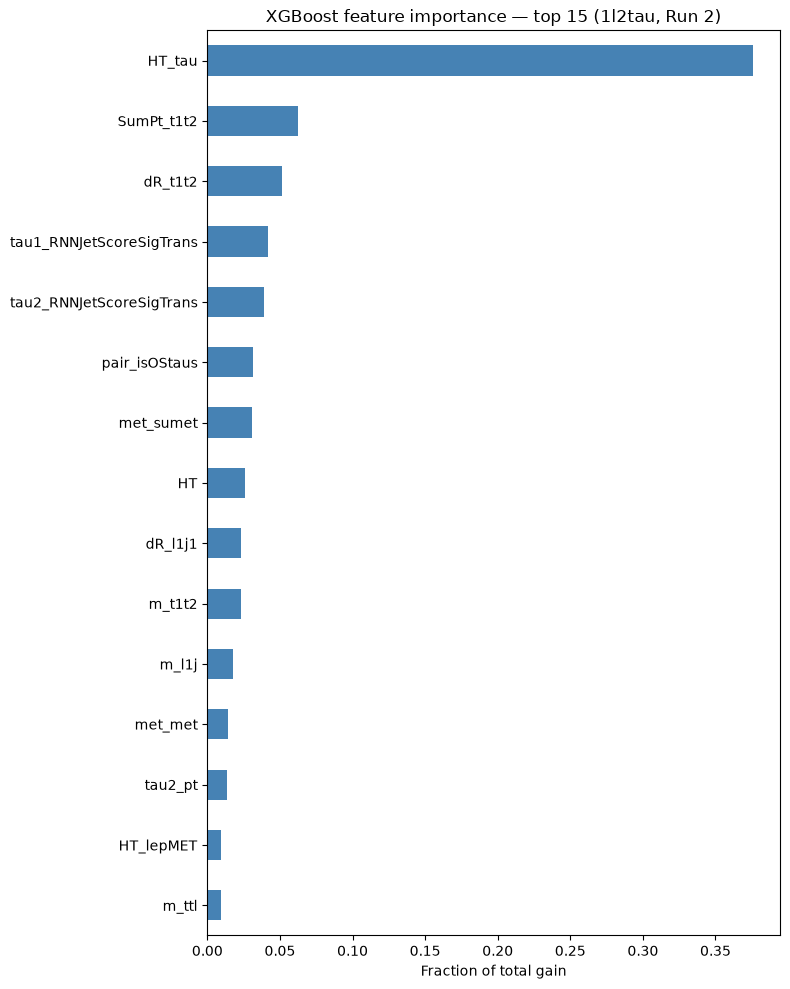

In [32]:
import matplotlib.pyplot as plt

# --- Feature importance ------------------------------------------------------
# total_gain = total loss reduction contributed by a feature (best for ranking).
booster = model.get_booster()

imp = pd.DataFrame({
    t: booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(features).fillna(0.0)

imp = imp.sort_values("total_gain", ascending=False)
imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()

print("Top 25 features by total gain:")
print(imp[["total_gain", "gain_frac", "weight"]].head(25).to_string())
print(f"\nFeatures never used in a split: {(imp['total_gain'] == 0).sum()} / {len(features)}")

TOP_N = 15

fig, ax = plt.subplots(figsize=(8, 10))

imp["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="steelblue")

ax.set_xlabel("Fraction of total gain")
ax.set_title(f"XGBoost feature importance — top {TOP_N} (1l2tau, Run 2)")
plt.tight_layout()
plt.show()


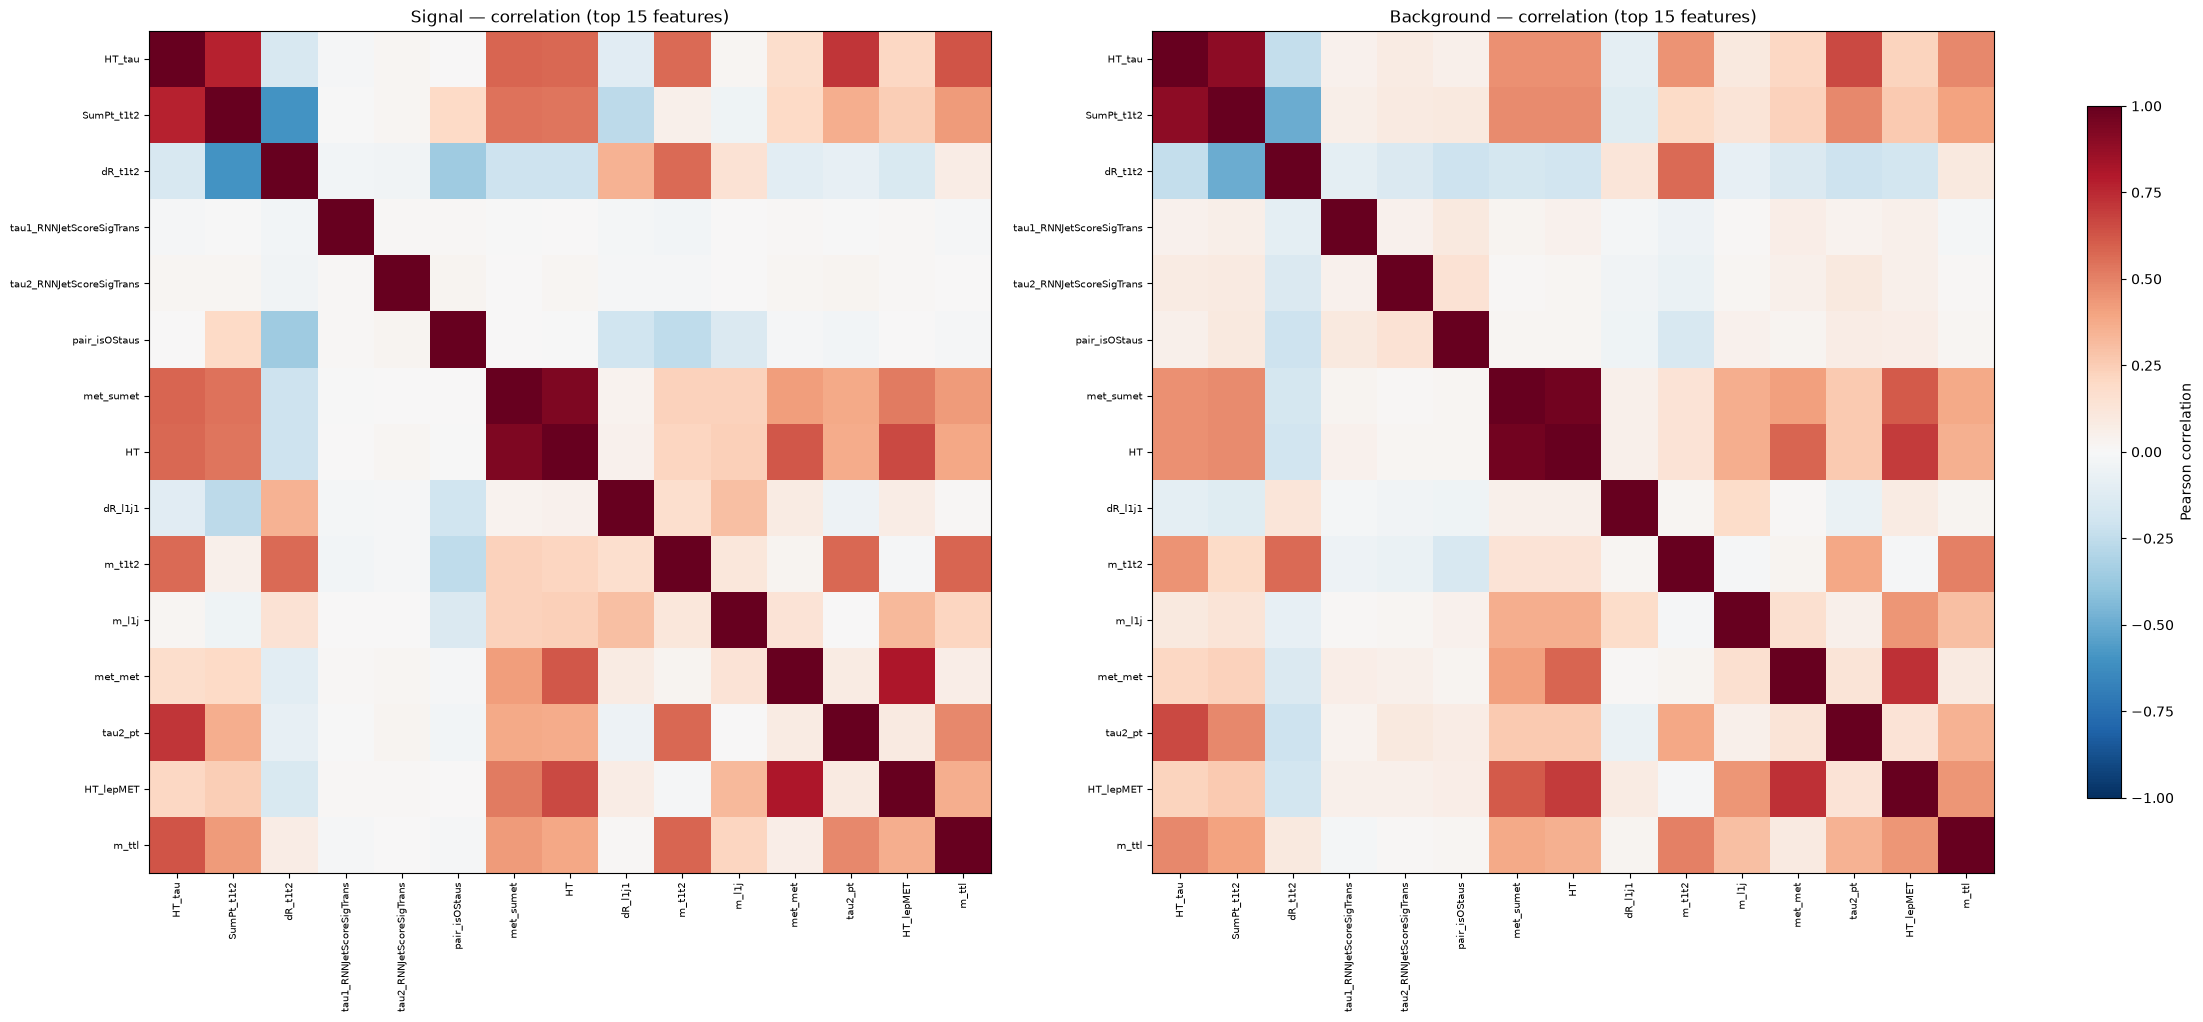

Pairs with |corr| > 0.9 (signal):
met_sumet  HT    0.93001

Pairs with |corr| > 0.9 (background):
met_sumet  HT    0.96535


In [33]:
# --- Correlation of the top features ----------------------------------------
# Pearson correlation among the TOP_N most important features, separately for
# signal and background (correlations differ between the two by physics).

top_feats = imp.index[:TOP_N].tolist()

corr_sig = data.loc[data.label == 1, top_feats].corr()
corr_bkg = data.loc[data.label == 0, top_feats].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
for ax, corr, title in [(axes[0], corr_sig, "Signal"), (axes[1], corr_bkg, "Background")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=7)
    ax.set_title(f"{title} — correlation (top {TOP_N} features)")

fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson correlation")

plt.show()

# Highly correlated pairs -> redundant, candidates to prune after importance

def top_pairs(corr, thr=0.9):
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]

print("Pairs with |corr| > 0.9 (signal):")
print(top_pairs(corr_sig).to_string())
print("\nPairs with |corr| > 0.9 (background):")
print(top_pairs(corr_bkg).to_string())


## Weights

In [8]:
for name in ["weight", "weights", "weight_final"]:   # ajustá a los nombres exactos
    try:
        w = tree[name].array(library="np")
        print(f"{name:15s}  suma={w.sum():.4g}  media={w.mean():.4g}  neg={(w<0).mean():.3f}")
    except Exception as e:
        print(f"{name:15s}  ERROR: {e}")

weight           suma=0.007813  media=2.534e-08  neg=0.000
weights          suma=7.724e+11  media=2.505e+06  neg=0.154
weight_final     suma=7.724e+11  media=2.505e+06  neg=0.154


In [9]:
w_norm  = tree["weight"].array(library="np")
w_gen   = tree["weight_final"].array(library="np")
w_total = w_norm * w_gen
print("suma:", w_total.sum(), "media:", w_total.mean(), "neg:", (w_total<0).mean())

suma: 20845.893134293878 media: 0.0676167084587615 neg: 0.15408618368770172


In [10]:
print(np.unique(w_norm).size, np.unique(w_norm)[:5])

54 [7.66539258e-09 7.85560044e-09 8.05634116e-09 8.51140018e-09
 8.85011554e-09]


In [12]:
print([k for k in tree.keys() if any(s in k.lower() for s in
       ["dsid", "sample", "mc_channel", "run", "period", "campaign"])])

['dsid']


In [19]:
import pandas as pd, numpy as np

dsid = tree["dsid"].array(library="np")
df = pd.DataFrame({"dsid": dsid, "w_norm": w_norm})

print("N DSIDs:", df.dsid.nunique())
print(df.groupby("dsid").w_norm.nunique())   # ¿cuántos valores de weight por DSID?        # ¿cuántos DSIDs?

N DSIDs: 18
dsid
700320    3
700321    3
700322    3
700323    3
700324    3
700325    3
700467    3
700468    3
700469    3
700470    3
700471    3
700472    3
700792    3
700793    3
700794    3
700901    3
700902    3
700903    3
Name: w_norm, dtype: int64


In [21]:
import uproot, numpy as np

path = "PPSSP_2026/1l2tau/run2/Zjets.root:AnalysisMiniTree"
tree = uproot.open(path)

arr = tree.arrays(
    ["weight", "weight_final", "weights", "weights_mc",
     "weights_detector", "weights_eff", "weight_ff"],
    library="np"
)

# 1) ¿weight_final es el producto de las tres?
prod = arr["weights_mc"] * arr["weights_detector"] * arr["weights_eff"]
print("weight_final == mc*det*eff :", np.allclose(prod, arr["weight_final"], rtol=1e-4))

# 2) ¿weights es duplicado de weight_final?
print("weights == weight_final    :", np.allclose(arr["weights"], arr["weight_final"], rtol=1e-4))

# 3) ¿Qué es weight_ff?
ff = arr["weight_ff"]
print("\nweight_ff:")
print("  únicos:", np.unique(ff)[:10])
print("  n únicos:", np.unique(ff).size)
print("  media:", ff.mean())
print("  fracción == 1:", (ff == 1).mean())
print("  fracción == 0:", (ff == 0).mean())

weight_final == mc*det*eff : True
weights == weight_final    : True

weight_ff:
  únicos: [1.]
  n únicos: 1
  media: 1.0
  fracción == 1: 1.0
  fracción == 0: 0.0
